#Actividad 6.1 - KMeans con dataset Iris (VOLUNTARIA)

In [1]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np
from sklearn.neighbors import LocalOutlierFactor



In [2]:

def BIC(K, grupos, X):
    N, P = X.shape  # Número de datos y variables
    xi = np.zeros((1, K))  # Vector xi

    for k in range(K):
        suma = 0
        for j in range(P):
            sigma = np.square(np.std(X[:, j]))
            sigma_j = np.square(np.std(X[grupos == k, j]))
            suma += 0.5 * np.log(sigma + sigma_j)

        n_k = sum(grupos == k)  # Número de elementos en el grupo k
        xi[0, k] = -n_k * suma

    bic = -2 * np.sum(xi) + 2 * K * P * np.log(N)
    return bic


1.Carga el dataset Iris.

In [3]:
datos = load_iris()

2.Crea un nuevo array X que contenga solo las columnas de atributos de longitud de pétalo y anchura de pétalo.

In [4]:
X = datos["data"][:, [2, 3]]

3.Haz estas modificaciones en X:
X[5,1]=10
X[20,0]=15

In [5]:
X[5, 1] = 10
X[20, 0] = 15

4.Muestra gráficamente los valores de X. Recuerda que no están agrupados, usa un solo color y forma para todas las observaciones.

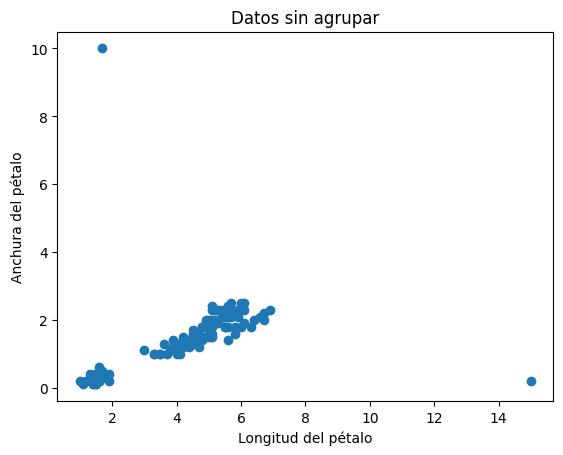

In [6]:
plt.scatter(X[:, 0], X[:, 1])
plt.xlabel('Longitud del pétalo')
plt.ylabel('Anchura del pétalo')
plt.title('Datos sin agrupar')
plt.show()

5.Entrena KMeans con X

5.1.Mediante BIC calcula el nº óptimo de grupos para KMeans con X.

Número óptimo de clusters según BIC: 5


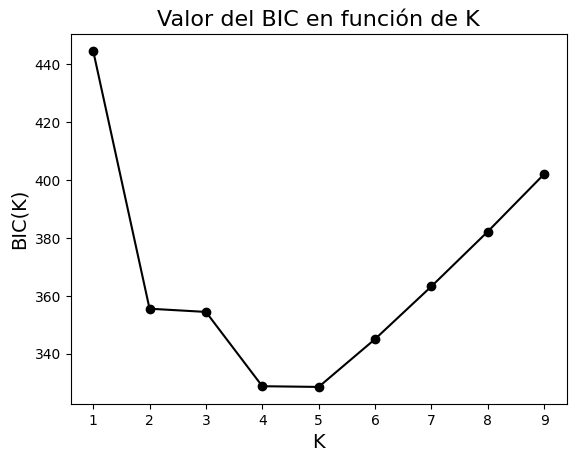

In [7]:
bic_scores = []
k_range = range(1, 10)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=10, n_init=10)
    grupos = kmeans.fit_predict(X)
    bic_scores.append(BIC(k, grupos, X))

k_optimo = np.argmin(bic_scores)+1
print(f'Número óptimo de clusters según BIC: {k_optimo}')

#Gráfica de valores del BIC
plt.plot(k_range, bic_scores, "ko-")
plt.title("Valor del BIC en función de K", fontsize=16)
plt.xlabel("K", fontsize=14)
plt.ylabel("BIC(K)", fontsize=14)
plt.show()

5.2.Entrena KMeans con X, con el valor óptimo de k obtenido.

In [8]:
kmeans_optimo = KMeans(n_clusters=k_optimo, random_state=10, n_init=10)
kmeans_optimo.fit(X)
predicciones = kmeans_optimo.predict(X)
centroides = kmeans_optimo.cluster_centers_

#print(predicciones)
#print(centroides)

5.3.Representa gráficamente el resultado del entrenamiento. Incluye los centroides en el gráfico.

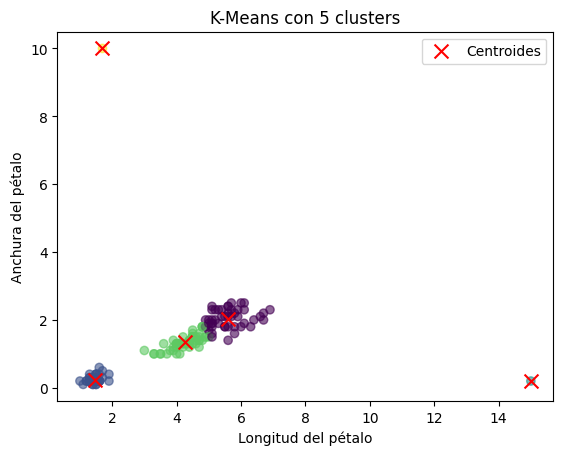

In [9]:
x_centroides, y_centroides = zip(*centroides)#Otra manera de asignar x e y
plt.scatter(X[:, 0], X[:, 1], c=predicciones, cmap='viridis', alpha=0.6)
plt.scatter(x_centroides, y_centroides, c='red', marker='x', s=100, label='Centroides')
plt.xlabel('Longitud del pétalo')
plt.ylabel('Anchura del pétalo')
plt.title(f'K-Means con {k_optimo} clusters')
plt.legend()
plt.show()

6.Calcula outliers influyentes. Muestra los resultados de forma gráfica y numérica.

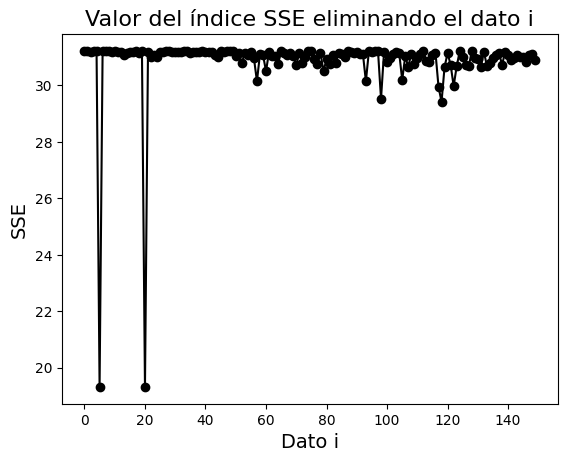

[5, 20]


In [10]:
N = X.shape[0] # Número de observaciones
K = 5 # Número de clusters

SSE = []
for i in range(0, N):
  X_sin_i = np.delete(X, i, axis=0) # Eliminamos la observación i
  # Aplicamos K-medias a X_sin_i y obtenemos el índice SSE
  kmeans = KMeans(n_clusters=K, n_init=10, random_state=100).fit(X_sin_i)
  SSE.append(kmeans.inertia_)


# Representación gráfica de los outliers
plt.plot(np.arange(0, N), SSE, "ko-")
plt.title("Valor del índice SSE eliminando el dato i", fontsize=16)
plt.xlabel("Dato i", fontsize=14)
plt.ylabel("SSE", fontsize=14)
plt.show()

#Eliminación outliers
sigma = np.std(SSE) # Desviación típica de SSE
mu = np.mean(SSE) # Media
umbral = 2 # Umbral: 2 para distribuciones normales y 3 para cualquier otra distribución

outliers = []
for i in range(0, N):
  if np.abs(SSE[i]-mu) > umbral*sigma:
    outliers.append(i)
print(outliers) #Efectivamente los outliers que pusimos al principio


7.Crea una X_nueva que contenga X sin los outliers influyentes.

In [11]:
X_nueva = np.delete(X, outliers, axis=0)

8.Entrena KMeans con X_nueva

8.1.Mediante BIC calcula el nº óptimo de grupos para KMeans con X_nueva.

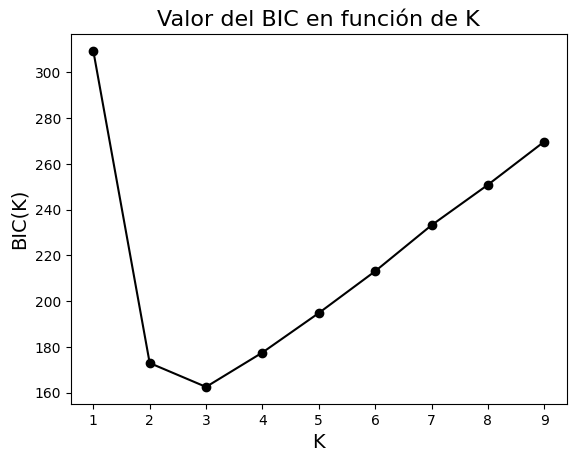

Número óptimo de clusters según BIC después de eliminar outliers: 3


In [15]:
bic_scores_nueva = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=10, n_init=10)
    grupos = kmeans.fit_predict(X_nueva)
    bic_scores_nueva.append(BIC(k, grupos, X_nueva))


# Evaluación del número óptimo de clusters con X_nueva
bic_scores_nueva = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=10, n_init=10)
    grupos = kmeans.fit_predict(X_nueva)
    bic_scores_nueva.append(BIC(k, grupos, X_nueva))


plt.plot(k_range, bic_scores_nueva, "ko-")
plt.title("Valor del BIC en función de K", fontsize=16)
plt.xlabel("K", fontsize=14)
plt.ylabel("BIC(K)", fontsize=14)
plt.show()

# Selección del número óptimo de clusters para X_nueva
k_optimo_nueva = k_range[np.argmin(bic_scores_nueva)]
print(f'Número óptimo de clusters según BIC después de eliminar outliers: {k_optimo_nueva}')


8.2.Entrena KMeans con X_nueva, con el valor óptimo de k obtenido.

In [13]:
kmeans_optimo_nueva = KMeans(n_clusters=k_optimo_nueva, random_state=10, n_init=10)
kmeans_optimo_nueva.fit(X_nueva)
predicciones_nueva = kmeans_optimo_nueva.predict(X_nueva)
centroides_nueva = kmeans_optimo_nueva.cluster_centers_

8.3.Representa gráficamente el resultado del entrenamiento. Incluye los centroides en el gráfico

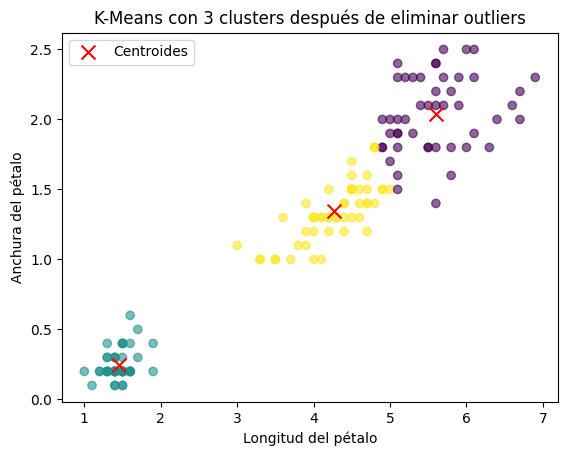

In [14]:
plt.scatter(X_nueva[:, 0], X_nueva[:, 1], c=predicciones_nueva, cmap='viridis', marker='o', alpha=0.6)
plt.scatter(centroides_nueva[:, 0], centroides_nueva[:, 1], c='red', marker='x', s=100, label='Centroides')
plt.xlabel('Longitud del pétalo')
plt.ylabel('Anchura del pétalo')
plt.title(f'K-Means con {k_optimo_nueva} clusters después de eliminar outliers')
plt.legend()
plt.show()